In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
DATA_DIR = "."

def read_idx_images(path):
    with open(path, "rb") as f:
        magic, n, rows, cols = np.frombuffer(f.read(16),dtype=">i4")
        data = np.frombuffer(f.read(),dtype=np.uint8)
    return data.reshape(n, rows, cols)


def read_idx_labels(path):
    with open(path, "rb") as f:
        magic, n = np.frombuffer(f.read(8),dtype=">i4")
        data = np.frombuffer(f.read(),dtype=np.uint8)
    return data.reshape(n,)

## Montar os caminhos

In [3]:
train_images_path = os.path.join(DATA_DIR, "train-images.idx3-ubyte")
train_labels_path = os.path.join(DATA_DIR, "train-labels.idx1-ubyte")

test_images_path = os.path.join(DATA_DIR, "t10k-images.idx3-ubyte")
test_labels_path = os.path.join(DATA_DIR, "t10k-labels.idx1-ubyte")

## Carregar os dados

In [4]:
x_train = read_idx_images(train_images_path)
y_train = read_idx_labels(train_labels_path)
x_test = read_idx_images(test_images_path)
y_test = read_idx_labels(test_labels_path)

## Ver uma amostra

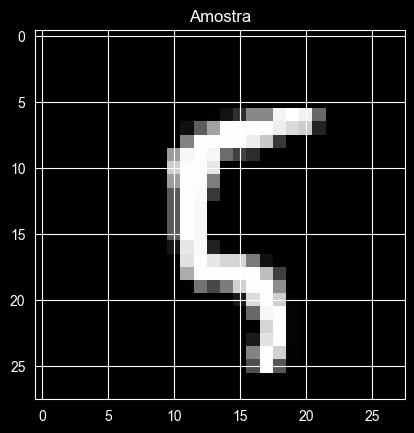

In [5]:
idx = 100
plt.figure()
plt.imshow(x_train[idx], cmap="gray")
plt.title("Amostra")
plt.show()

## Ver a matriz

In [6]:
idx = 300
matriz = x_train[idx].squeeze()
print(matriz)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 138 238
  217  68   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 150 254 254
  254 232   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  63 224 254 145
  254 240  22   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  15 160 253 25

## Pré-processamento

In [7]:
x_train = (x_train.astype("float32")/255.0)[...,None]
x_test = (x_test.astype("float32")/255.0)[...,None]
y_train_oh = tf.keras.utils.to_categorical(y_train,10)
y_test_oh = tf.keras.utils.to_categorical(y_test,10)

## Criação do modelo

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16,3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

## Compila definindo o Loss e métrica de avaliação

In [9]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

## Treino da CNN

In [10]:
history = model.fit(
    x_train, y_train_oh,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=2
)

Epoch 1/10
422/422 - 10s - loss: 0.3397 - accuracy: 0.8978 - val_loss: 0.0896 - val_accuracy: 0.9750 - 10s/epoch - 24ms/step
Epoch 2/10
422/422 - 9s - loss: 0.0886 - accuracy: 0.9726 - val_loss: 0.0656 - val_accuracy: 0.9820 - 9s/epoch - 20ms/step
Epoch 3/10
422/422 - 9s - loss: 0.0639 - accuracy: 0.9803 - val_loss: 0.0582 - val_accuracy: 0.9842 - 9s/epoch - 21ms/step
Epoch 4/10
422/422 - 9s - loss: 0.0514 - accuracy: 0.9840 - val_loss: 0.0461 - val_accuracy: 0.9868 - 9s/epoch - 21ms/step
Epoch 5/10
422/422 - 8s - loss: 0.0426 - accuracy: 0.9867 - val_loss: 0.0421 - val_accuracy: 0.9883 - 8s/epoch - 20ms/step
Epoch 6/10
422/422 - 8s - loss: 0.0351 - accuracy: 0.9894 - val_loss: 0.0506 - val_accuracy: 0.9858 - 8s/epoch - 19ms/step
Epoch 7/10
422/422 - 14s - loss: 0.0309 - accuracy: 0.9907 - val_loss: 0.0404 - val_accuracy: 0.9887 - 14s/epoch - 33ms/step
Epoch 8/10
422/422 - 50s - loss: 0.0274 - accuracy: 0.9913 - val_loss: 0.0382 - val_accuracy: 0.9892 - 50s/epoch - 117ms/step
Epoch 9/1

## Apresentar o resultado do modelo

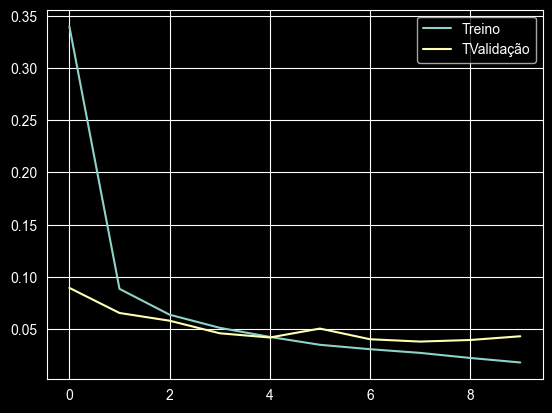

In [11]:
plt.plot(history.history["loss"],label="Treino")
plt.plot(history.history["val_loss"],label="TValidação")
plt.legend()

## Salvar Modelo

In [11]:
model.save("cnn_mnist_model.keras")
#importar o modelo
model = tf.keras.models.load_model("cnn_mnist_model.keras")

## Testar a predição do modelo

In [12]:
y_pred = np.argmax(model.predict(x_test, verbose = 0), axis = 1)
y_true = y_test

## Métricas de avaliação

In [13]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.97      1.00      0.98      1010
           4       1.00      0.99      0.99       982
           5       0.98      0.98      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.98      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Matriz de confusão

In [14]:
cm = tf.math.confusion_matrix(y_true, y_pred).numpy()

In [15]:
print(cm)

[[ 974    0    0    0    0    1    3    1    1    0]
 [   0 1131    0    1    0    0    1    1    0    1]
 [   0    1 1024    2    0    0    1    3    1    0]
 [   0    0    0 1005    0    3    0    0    2    0]
 [   0    1    1    0  970    0    3    1    0    6]
 [   1    0    1   10    0  877    2    0    1    0]
 [   2    2    1    0    1    5  947    0    0    0]
 [   0    1    7    4    0    1    0 1013    1    1]
 [   2    0    2    4    0    4    0    2  958    2]
 [   0    2    1    5    3    6    0    3    2  987]]


# HeatMap da matriz de confusão

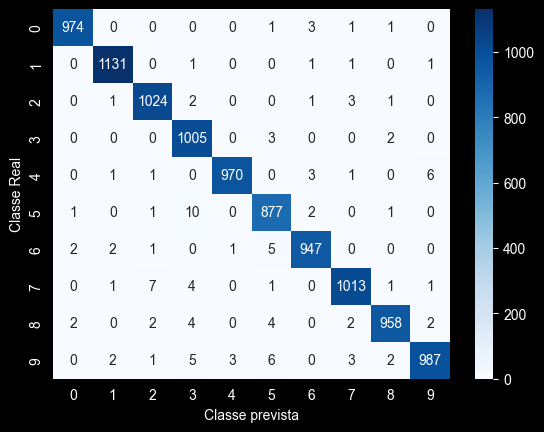

In [17]:
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Classe prevista")
plt.ylabel("Classe Real")
plt.show()